In [1]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, BatchNormalization, Dropout, TimeDistributed, RepeatVector
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import xlsxwriter

%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("../Cleaned_Dataset/updated_Aggregated_data.xlsx")
df.head()

,unique_id,inci_no,inci_type,incident_category,Incident_Type_Description,Property_Loss_Value,Content_Loss_Value,Property_Value,Content_Value,Civilian_Fatal,...,Longitude,Latitude,DAUID,average_temperature,precipitation,relative_humidity,average_snowfall,wind_speed,wind_direction,incident_category_description
0,370799,20-0000001,99,J,Other Response,0,0,0,0,0,...,-79.660289,44.364600,35431002,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Other Response
1,370800,20-0000002,86,I,Alcohol or drug related,0,0,0,0,0,...,-79.725625,44.324085,35430707,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Medical/Resuscitator Call
2,370801,20-0000003,86,I,Alcohol or drug related,0,0,0,0,0,...,-79.688440,44.389289,35431060,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Medical/Resuscitator Call
3,370802,20-0000004,89,I,Other Medical/Resuscitator Call,0,0,0,0,0,...,-79.719359,44.360078,35430669,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Medical/Resuscitator Call
4,370807,20-0000005,86,I,Alcohol or drug related,0,0,0,0,0,...,-79.691135,44.390391,35431050,-1.128695,2.0,84.14099,1.82,51.826096,274.41022,Medical/Resuscitator Call


In [3]:
df.shape

(40814, 28)

In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

unique_id                          0
inci_no                            0
inci_type                          0
incident_category                  0
Incident_Type_Description          0
Property_Loss_Value                0
Content_Loss_Value                 0
Property_Value                     0
Content_Value                      0
Civilian_Fatal                     0
Civilian_Injuries                  0
prop_use                           0
Property_Damage_Category           0
Property_Damage_Description        0
Received_Datetime                  0
Dispatched_Datetime                0
Arrival_Datetime                 408
Cleared_Datetime                   4
Longitude                          0
Latitude                           0
DAUID                              0
average_temperature                0
precipitation                      0
relative_humidity                  0
average_snowfall                   0
wind_speed                         0
wind_direction                     0
i

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Convert datetime columns to datetime format
df['Received_Datetime'] = pd.to_datetime(df['Received_Datetime'])
df['Dispatched_Datetime'] = pd.to_datetime(df['Dispatched_Datetime'])
df['Arrival_Datetime'] = pd.to_datetime(df['Arrival_Datetime'])
df['Cleared_Datetime'] = pd.to_datetime(df['Cleared_Datetime'])
df.sort_values('Received_Datetime', inplace=True)

# Encode categorical features
label_encoders = {}
categorical_columns = ['incident_category_description', 'DAUID', 'prop_use', 'Property_Damage_Category']
for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le
    num_unique_categories = len(le.classes_)
    print(f"Number of unique categories in '{column}': {num_unique_categories}")

# Define aggregation function for numeric columns
agg_funcs = {
    'Property_Loss_Value': 'mean',
    'Content_Loss_Value': 'mean',
    'Property_Value': 'mean',
    'Content_Value': 'mean',
    'Civilian_Fatal': 'sum',
    'Civilian_Injuries': 'sum',
    'prop_use': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'Property_Damage_Category': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'Longitude': 'mean',
    'Latitude': 'mean',
    'average_temperature': 'mean',
    'precipitation': 'mean',
    'relative_humidity': 'mean',
    'average_snowfall': 'mean',
    'wind_speed': 'mean',
    'wind_direction': 'mean',
    'incident_category_description': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'DAUID': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'Dispatched_Datetime': 'first',
    'Arrival_Datetime': 'first',
    'Cleared_Datetime': 'first'
}

# Resample the data at 15-minute intervals and aggregate
df.set_index('Received_Datetime', inplace=True)
df_resampled = df.resample('15T').agg(agg_funcs).ffill().reset_index()

# Define sequence length (n_steps) and output sequence length (n_output_steps)
n_steps = 16  # Number of previous steps to consider for prediction
n_output_steps = 10  # Number of steps ahead to predict

# List of columns to be used for prediction
numerical_columns = [
    'Property_Loss_Value', 'Content_Loss_Value', 'Property_Value', 'Content_Value', 
    'Civilian_Fatal', 'Civilian_Injuries', 'Longitude', 'Latitude', 
    'average_temperature', 'precipitation', 'relative_humidity', 
    'average_snowfall', 'wind_speed', 'wind_direction'
]

feature_columns = ['DAUID', 'incident_category_description', 'prop_use', 'Property_Damage_Category'] + numerical_columns

# Scale the numerical features
scaler = StandardScaler()
df_resampled[numerical_columns] = scaler.fit_transform(df_resampled[numerical_columns])

# Output columns
output_columns = ['DAUID', 'incident_category_description']

# One-hot encode the output labels
onehot_encoder_dauid = OneHotEncoder(sparse_output=False)
onehot_encoder_category = OneHotEncoder(sparse_output=False)
y_dauid_encoded = onehot_encoder_dauid.fit_transform(df_resampled[['DAUID']])
y_category_encoded = onehot_encoder_category.fit_transform(df_resampled[['incident_category_description']])

# Initialize lists to store sequences
sequences_x = []
sequences_y_dauid = []
sequences_y_category = []

for i in range(len(df_resampled) - n_steps - n_output_steps + 1):
    x_seq = df_resampled.iloc[i:i+n_steps][feature_columns].values
    sequences_x.append(x_seq)
    
    y_dauid_seq = y_dauid_encoded[i+n_steps:i+n_steps+n_output_steps]
    y_category_seq = y_category_encoded[i+n_steps:i+n_steps+n_output_steps]
    
    sequences_y_dauid.append(y_dauid_seq)
    sequences_y_category.append(y_category_seq)

# Convert lists to numpy arrays
x = np.array(sequences_x)
y_dauid = np.array(sequences_y_dauid)
y_category = np.array(sequences_y_category)



Number of unique categories in 'incident_category_description': 10
Number of unique categories in 'DAUID': 246
Number of unique categories in 'prop_use': 245
Number of unique categories in 'Property_Damage_Category': 55


In [6]:
# Check the shape of x, y_dauid, and y_category arrays
print("Shape of x:", x.shape)  # Expected shape: (num_samples, n_steps, num_features)
print("Shape of y_dauid:", y_dauid.shape)  # Expected shape: (num_samples, num_output_steps, num_classes_dauid)
print("Shape of y_category:", y_category.shape)  # Expected shape: (num_samples, num_output_steps, num_classes_category)

# Split the data into training, validation, and testing sets
x_train, x_temp, y_dauid_train, y_dauid_temp, y_category_train, y_category_temp = train_test_split(x, y_dauid, y_category, test_size=0.3, random_state=42)
x_val, x_test, y_dauid_val, y_dauid_test, y_category_val, y_category_test = train_test_split(x_temp, y_dauid_temp, y_category_temp, test_size=0.5, random_state=42)

print("Shape of x_test:", x_test.shape)
print("Shape of y_dauid_test:", y_dauid_test.shape)
print("Shape of y_category_test:", y_category_test.shape)

Shape of x: (140227, 16, 18)
Shape of y_dauid: (140227, 10, 246)
Shape of y_category: (140227, 10, 10)
Shape of x_test: (21035, 16, 18)
Shape of y_dauid_test: (21035, 10, 246)
Shape of y_category_test: (21035, 10, 10)


In [13]:
# # Flatten x_test to 2D for saving to Excel
# x_test_flattened =  x_test.reshape(x_test.shape[0], -1) 
# x_test_df = pd.DataFrame(x_test_flattened)
# x_test_df.to_excel('../Backend-app/Test_data/LSTM_test_data/x_test10.xlsx', index=False, engine='openpyxl')

# Flatten y_dauid_test to 2D for saving to Excel
y_dauid_test_flattened = y_dauid_test.reshape(y_dauid_test.shape[0], -1)
y_dauid_test_df = pd.DataFrame(y_dauid_test_flattened)
y_dauid_test_df.to_excel('../Backend-app/Test_data/LSTM_test_data/y_dauid_test10.xlsx', index=False, engine='xlsxwriter')
# Flatten y_category_test to 2D for saving to Excel
# y_category_test_flattened = y_category_test.reshape(y_category_test.shape[0], -1)
# y_category_test_df = pd.DataFrame(y_category_test_flattened)
# y_category_test_df.to_excel('../Backend-app/Test_data/LSTM_test_data/y_category_test8.xlsx', index=False, engine='openpyxl')

# Verify flattened shapes and sizes
print("Shape of x_test_df:", x_test_df.shape)
print("Shape of y_dauid_test_df:", y_dauid_test_df.shape)
print("Shape of y_category_test_df:", y_category_test_df.shape)

NameError: name 'x_test_df' is not defined

In [33]:
# Saving to Excel with xlsxwriter engine
y_category_test_flattened = y_category_test.reshape(y_category_test.shape[0], -1)
y_category_test_df = pd.DataFrame(y_category_test_flattened)
y_category_test_df.to_excel('../Backend-app/Test_data/LSTM_test_data/y_category_test10.xlsx', index=False, engine='xlsxwriter')

In [7]:
model = Sequential()
model.add(Bidirectional(LSTM(50, activation='relu'), input_shape=(n_steps, x.shape[2])))
model.add(BatchNor0.2))
model.add(Dense(50, activation='relu'))
model.add(RepeatVector(n_output_steps))  # Repeat the context vector for each output step
model.add(Bidirectional(LSTM(50, activation='relu', return_sequences=True)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(TimeDistributed(Dense(50, activation='relu')))
          
# Output layers for DAUID and incident category
dauid_output = TimeDistributed(Dense(len(label_encoders['DAUID'].classes_), activation='softmax'), name='dauid_output')(model.layers[-1].output)
category_output = TimeDistributed(Dense(len(label_encoders['incident_category_description'].classes_), activation='softmax'), name='category_output')(model.layers[-1].output)

model = Model(inputs=model.inputs, outputs=[dauid_output, category_output])

model.compile(optimizer='adam', loss={'dauid_output': 'categorical_crossentropy', 'category_output': 'categorical_crossentropy'}, metrics={'dauid_output': ['accuracy'], 'category_output': ['accuracy']})

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

# Fit the model
history = model.fit(x_train, {'dauid_output': y_dauid_train, 'category_output': y_category_train},
                    epochs=200, verbose=1, validation_data=(x_val, {'dauid_output': y_dauid_val, 'category_output': y_category_val}),
                    callbacks=[early_stopping, reduce_lr])


Epoch 1/200
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 53s 16ms/step - category_output_accuracy: 0.6857 - dauid_output_accuracy: 0.0291 - loss: 6.3736 - val_category_output_accuracy: 0.7103 - val_dauid_output_accuracy: 0.0396 - val_loss: 6.0735 - learning_rate: 0.0010
Epoch 2/200
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - category_output_accuracy: 0.7118 - dauid_output_accuracy: 0.0396 - loss: 6.0769 - val_category_output_accuracy: 0.7100 - val_dauid_output_accuracy: 0.0514 - val_loss: 5.9910 - learning_rate: 0.0010
Epoch 3/200
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - category_output_accuracy: 0.7121 - dauid_output_accuracy: 0.0471 - loss: 6.0115 - val_category_output_accuracy: 0.7104 - val_dauid_output_accuracy: 0.0546 - val_loss: 5.9493 - learning_rate: 0.0010
Epoch 4/200
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - category_output_accuracy: 0.7106 - dauid_output_accuracy: 0.0523 - loss: 5.9666 - val_category_output_accuracy: 0.7109 - val_dauid_output_accuracy: 0.0622 - val_loss: 5.9

658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Decoded Predicted DAUID: [[35430670 35430668 35430668 ... 35430668 35430668 35431050]
 [35431067 35431067 35431067 ... 35431060 35431060 35431060]
 [35431321 35431321 35431324 ... 35431321 35431321 35431321]
 ...
 [35430670 35430670 35430670 ... 35430670 35431019 35431060]
 [35431054 35431054 35431054 ... 35431054 35431054 35431054]
 [35431071 35431071 35431071 ... 35431073 35431060 35431060]]
Decoded True DAUID: [[35430652 35431001 35431001 ... 35431050 35431050 35431050]
 [35431075 35431075 35431075 ... 35431024 35431046 35431316]
 [35431324 35431346 35431346 ... 35431346 35430667 35430667]
 ...
 [35430670 35430670 35430670 ... 35430670 35430670 35430670]
 [35431060 35431060 35431060 ... 35431060 35431060 35431060]
 [35431071 35431318 35431318 ... 35430670 35430670 35430670]]
Decoded Predicted Category: [['Medical/Resuscitator Call' 'Medical/Resuscitator Call'
  'Medical/Resuscitator Call' ... 'Medical/Resuscitator Call'
  'Medical/Resuscitato

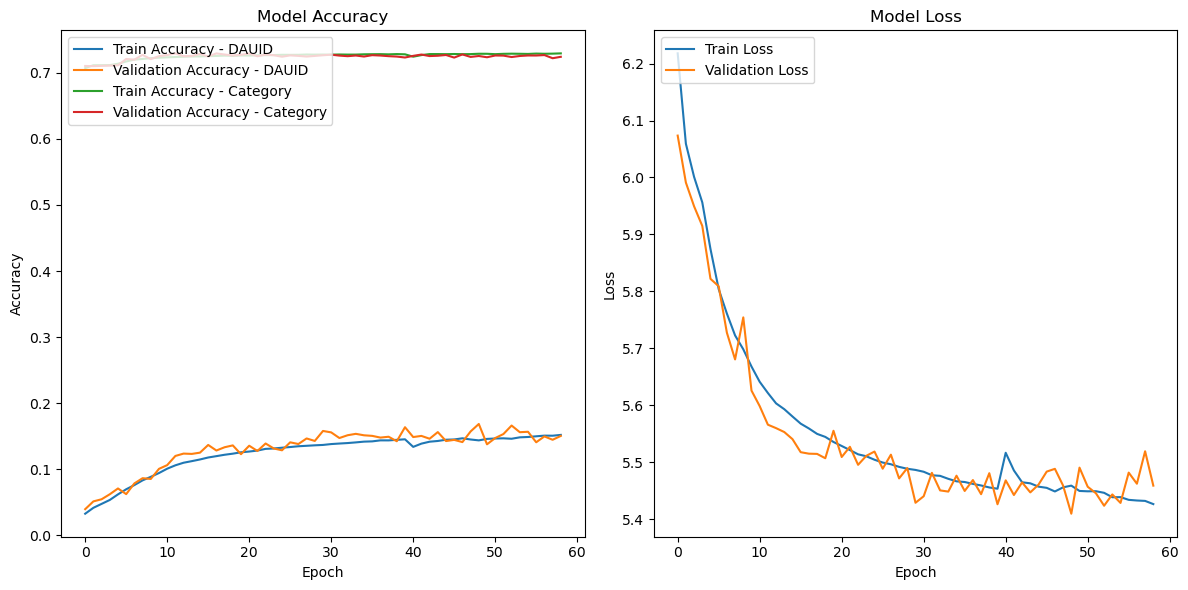

In [12]:
# Make predictions on the test set
predictions = model.predict(x_test)

# Separate the predictions for DAUID and incident_category_description
predicted_dauid = np.argmax(predictions[0], axis=2)
predicted_category = np.argmax(predictions[1], axis=2)

# Flatten the predictions to 1D arrays
flattened_predicted_dauid = predicted_dauid.flatten()
flattened_predicted_category = predicted_category.flatten()

# Decode the predictions and true values back to original labels
decoded_predicted_dauid = label_encoders['DAUID'].inverse_transform(flattened_predicted_dauid)
decoded_true_dauid = label_encoders['DAUID'].inverse_transform(np.argmax(y_dauid_test, axis=2).flatten())

decoded_predicted_category = label_encoders['incident_category_description'].inverse_transform(flattened_predicted_category)
decoded_true_category = label_encoders['incident_category_description'].inverse_transform(np.argmax(y_category_test, axis=2).flatten())

# Reshape decoded labels back to the original sequence shape
decoded_predicted_dauid = decoded_predicted_dauid.reshape(predicted_dauid.shape)
decoded_true_dauid = decoded_true_dauid.reshape(predicted_dauid.shape)

decoded_predicted_category = decoded_predicted_category.reshape(predicted_category.shape)
decoded_true_category = decoded_true_category.reshape(predicted_category.shape)

print("Decoded Predicted DAUID:", decoded_predicted_dauid)
print("Decoded True DAUID:", decoded_true_dauid)

print("Decoded Predicted Category:", decoded_predicted_category)
print("Decoded True Category:", decoded_true_category)

# Calculate accuracy for each time step and average them
dauid_accuracies = [accuracy_score(decoded_true_dauid[:, i], decoded_predicted_dauid[:, i]) for i in range(n_output_steps)]
category_accuracies = [accuracy_score(decoded_true_category[:, i], decoded_predicted_category[:, i]) for i in range(n_output_steps)]

# Average accuracies
average_dauid_accuracy = np.mean(dauid_accuracies)
average_category_accuracy = np.mean(category_accuracies)

print(f"Average DAUID Accuracy: {average_dauid_accuracy * 100:.2f}%")
print(f"Average Category Accuracy: {average_category_accuracy * 100:.2f}%")


# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['dauid_output_accuracy'], label='Train Accuracy - DAUID')
plt.plot(history.history['val_dauid_output_accuracy'], label='Validation Accuracy - DAUID')
plt.plot(history.history['category_output_accuracy'], label='Train Accuracy - Category')
plt.plot(history.history['val_category_output_accuracy'], label='Validation Accuracy - Category')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [15]:
import pandas as pd
import numpy as np
import pickle

# Assuming x_test, y_dauid_test, and y_category_test are your numpy arrays

# Save the label encoders
with open('../Backend-app/Trained_models/LSTM/label_encoders10.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

In [9]:
# Save model architecture to JSON
model_json = model.to_json()
with open("../Backend-app/Trained_models/LSTM/10output_model.json", "w") as json_file:
    json_file.write(model_json)

# Save weights to HDF5
model.save_weights("../Backend-app/Trained_models/LSTM/10output_model.weights.h5")

In [10]:
import json
from tensorflow.keras.models import model_from_json

class KerasModelWrapper:
    def __init__(self, model=None):
        self.model = model

    def save(self, model_json_path, model_weights_path):
        # Save model architecture to JSON
        model_json = self.model.to_json()
        with open(model_json_path, "w") as json_file:
            json_file.write(model_json)
        # Save weights to HDF5
        self.model.save_weights(model_weights_path)

    def load(self, model_json_path, model_weights_path):
        # Load model architecture from JSON
        with open(model_json_path, "r") as json_file:
            loaded_model_json = json_file.read()
        self.model = model_from_json(loaded_model_json)
        # Load weights into the new model
        self.model.load_weights(model_weights_path)

In [11]:
import pickle

# Create a wrapper instance
wrapper = KerasModelWrapper(model)

# Save the wrapper class with model architecture and weights
with open("../Backend-app/Trained_models/LSTM/10output_model_wrapper.pkl", "wb") as f:
    pickle.dump(wrapper, f)

# To load the model later
with open("../Backend-app/Trained_models/LSTM/10output_model_wrapper.pkl", "rb") as f:
    loaded_wrapper = pickle.load(f)

# Load the model architecture and weights
loaded_wrapper.load("../Backend-app/Trained_models/LSTM/10output_model.json", "../Backend-app/Trained_models/LSTM/10output_model.weights.h5")
loaded_model = loaded_wrapper.model

# Now loaded_model is ready to be used
loaded_model.predict(x_test)

658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


[array([[[5.21874836e-06, 3.67319481e-05, 7.94933221e-05, ...,
          9.54342482e-04, 4.17529918e-05, 1.37075636e-04],
         [1.26106577e-04, 1.69110674e-04, 2.94915691e-04, ...,
          2.04816740e-03, 1.80160438e-04, 1.06056756e-03],
         [2.03453252e-04, 2.46300333e-04, 3.84998071e-04, ...,
          2.04929011e-03, 2.42940776e-04, 1.26401172e-03],
         ...,
         [9.42726620e-04, 1.12637749e-03, 1.11904740e-03, ...,
          3.56927072e-03, 5.41245157e-04, 3.19887511e-03],
         [6.99161494e-04, 1.34022406e-03, 1.19842438e-03, ...,
          4.07395978e-03, 5.73864731e-04, 3.41105554e-03],
         [5.52127545e-04, 1.44952745e-03, 1.19309640e-03, ...,
          4.08905093e-03, 6.31530886e-04, 3.22685926e-03]],
 
        [[2.17138477e-05, 9.71027475e-04, 9.08652146e-04, ...,
          1.18365488e-03, 2.22149916e-04, 1.71894650e-03],
         [4.66207130e-05, 1.66105304e-03, 1.55518984e-03, ...,
          1.65671972e-03, 3.32521537e-04, 2.47984519e-03],
       